# exp007 — Late Fusion on Balanced 40k Split

Canonical notebook name:

```text
/home/jovyan/MSC_PROJECT/exp007_late_fusion_bal40k.ipynb
```

Short experiment folder:

```text
exp007_late_fusion_bal40k
```

This experiment combines the visual temporal model and audio temporal model to predict whether **any modality** is fake.

The unimodal experiments are modality-specific:

```text
Visual temporal model: which visual frames are fake?
Audio temporal model: which audio windows are fake?
```

Fusion converts those modality scores into the binary multimodal task:

```text
Is the clip fake in either audio or visual modality?
```

## Condition logic

| Condition | Binary fake? | Visual fake? | Audio fake? | Expected fusion behaviour |
|---|---:|---:|---:|---|
| `real` | 0 | 0 | 0 | both scores low |
| `fake_video_real_audio` | 1 | 1 | 0 | visual high, audio low |
| `real_video_fake_audio` | 1 | 0 | 1 | visual low, audio high |
| `fake_video_fake_audio` | 1 | 1 | 1 | both scores high |

Rule-based OR fusion:

```text
p_fusion = 1 - (1 - p_visual) * (1 - p_audio)
```

This notebook also trains a tiny logistic regression fusion model on the train split scores.

## Important

This notebook should not decode video or audio again. It loads cached feature shards and checkpoints from:

```text
exp004_visual_temporal_bal40k
exp005_audio_temporal_bal40k
```

So those feature shards must still exist on JHub, even though they were excluded from exported zip files.

In [1]:
# Cell 1 — Imports and reproducibility

from pathlib import Path
from datetime import datetime
import json
import shutil
import zipfile
import hashlib
import random
import gc

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import FileLink, display

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.set_float32_matmul_precision("high")

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.3.1+cu121
CUDA available: True
GPU: NVIDIA A40


/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Cell 2 — Paths

PROJECT_ROOT = Path("/home/jovyan/MSC_PROJECT")
EXPERIMENTS_DIR = PROJECT_ROOT / "experiments"
EXPORTS_DIR = PROJECT_ROOT / "exports"
EXPORTS_DIR.mkdir(parents=True, exist_ok=True)

NOTEBOOK_FILENAME = "exp007_late_fusion_bal40k.ipynb"
NOTEBOOK_PATH = PROJECT_ROOT / NOTEBOOK_FILENAME

CONDITION_COL = "condition"
PATH_COL = "path"
RELATIVE_PATH_COL = "relative_path"
SPLITS = ["train", "val", "test"]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("EXPECTED NOTEBOOK_PATH:", NOTEBOOK_PATH)
print("Notebook exists at expected path:", NOTEBOOK_PATH.exists())

PROJECT_ROOT: /home/jovyan/MSC_PROJECT
EXPECTED NOTEBOOK_PATH: /home/jovyan/MSC_PROJECT/exp007_late_fusion_bal40k.ipynb
Notebook exists at expected path: True


In [3]:
# Cell 3 — Experiment config

EXPERIMENT_ID = "exp007"
EXPERIMENT_NAME = "late_fusion_bal40k"
RUN_NAME = f"{EXPERIMENT_ID}_{EXPERIMENT_NAME}"

VISUAL_SOURCE_CANDIDATES = [
    "exp004_visual_temporal_bal40k",
    "004_visual_temporal_bal40k",
]

AUDIO_SOURCE_CANDIDATES = [
    "exp005_audio_temporal_bal40k",
    "005_audio_temporal_bal40k",
]

VISUAL_FEATURE_DIR_CANDIDATES = [
    "visual_temporal_convnext_base_64f",
    "visual_temporal_convnext_base_64frames",
]

AUDIO_FEATURE_DIR_CANDIDATES = [
    "audio_logstft_rawcopy_64w",
    "audio_logstft_s16_64w",
    "audio_logstft_64w",
]

DEFAULT_THRESHOLD = 0.5
TOPK_FRACTIONS = [0.05, 0.10, 0.20]

EXPERIMENT_CONFIG = {
    "run_name": RUN_NAME,
    "task": "late fusion of visual and audio temporal models on balanced split",
    "fusion_target": "binary_label / any manipulated modality",
    "fusion_methods": ["visual_only", "audio_only", "or_fusion", "mean_fusion", "max_fusion", "logistic_regression"],
    "default_threshold": DEFAULT_THRESHOLD,
    "seed": SEED,
}

EXPERIMENT_CONFIG

{'run_name': 'exp007_late_fusion_bal40k',
 'task': 'late fusion of visual and audio temporal models on balanced split',
 'fusion_target': 'binary_label / any manipulated modality',
 'fusion_methods': ['visual_only',
  'audio_only',
  'or_fusion',
  'mean_fusion',
  'max_fusion',
  'logistic_regression'],
 'default_threshold': 0.5,
 'seed': 42}

In [4]:
# Cell 4 — Experiment folder setup

def setup_experiment_short(project_root, run_name, config):
    run_dir = Path(project_root) / "experiments" / run_name
    dirs = {
        "run": run_dir,
        "manifests": run_dir / "manifests",
        "results": run_dir / "results",
        "checkpoints": run_dir / "checkpoints",
        "plots": run_dir / "plots",
        "notebook": run_dir / "notebook",
    }
    for d in dirs.values():
        d.mkdir(parents=True, exist_ok=True)

    config = dict(config)
    config["created_at"] = datetime.now().isoformat(timespec="seconds")
    with open(run_dir / "config.json", "w") as f:
        json.dump(config, f, indent=4)

    print("Experiment folder:", run_dir)
    return dirs

RUN_DIRS = setup_experiment_short(PROJECT_ROOT, RUN_NAME, EXPERIMENT_CONFIG)
RUN_MANIFEST_DIR = RUN_DIRS["manifests"]
RESULTS_DIR = RUN_DIRS["results"]
CHECKPOINT_DIR = RUN_DIRS["checkpoints"]
PLOTS_DIR = RUN_DIRS["plots"]

Experiment folder: /home/jovyan/MSC_PROJECT/experiments/exp007_late_fusion_bal40k


In [6]:
# Cell 5 — Locate source experiments and feature dirs

def find_run_dir(candidates):
    for name in candidates:
        p = EXPERIMENTS_DIR / name
        if p.exists():
            return name, p
    raise FileNotFoundError("Could not find any of: " + ", ".join(candidates))


def find_feature_dir(run_dir, candidates):
    root = Path(run_dir) / "features"
    checked = []
    for name in candidates:
        p = root / name
        checked.append(str(p))
        if p.exists() and all((p / split / "shard_manifest.csv").exists() for split in SPLITS):
            return p
    raise FileNotFoundError("No complete feature dir found. Checked:" + "".join(checked))

VISUAL_SOURCE_NAME, VISUAL_RUN_DIR = find_run_dir(VISUAL_SOURCE_CANDIDATES)
AUDIO_SOURCE_NAME, AUDIO_RUN_DIR = find_run_dir(AUDIO_SOURCE_CANDIDATES)

VISUAL_FEATURE_DIR = find_feature_dir(VISUAL_RUN_DIR, VISUAL_FEATURE_DIR_CANDIDATES)
AUDIO_FEATURE_DIR = find_feature_dir(AUDIO_RUN_DIR, AUDIO_FEATURE_DIR_CANDIDATES)

VISUAL_CHECKPOINT = VISUAL_RUN_DIR / "checkpoints" / "best_temporal_head.pt"
AUDIO_CHECKPOINT = AUDIO_RUN_DIR / "checkpoints" / "best_audio_temporal_head.pt"

if not VISUAL_CHECKPOINT.exists():
    raise FileNotFoundError(VISUAL_CHECKPOINT)
if not AUDIO_CHECKPOINT.exists():
    raise FileNotFoundError(AUDIO_CHECKPOINT)

print("Visual source:", VISUAL_SOURCE_NAME)
print("Visual feature dir:", VISUAL_FEATURE_DIR)
print("Visual checkpoint:", VISUAL_CHECKPOINT)
print("Audio source:", AUDIO_SOURCE_NAME)
print("Audio feature dir:", AUDIO_FEATURE_DIR)
print("Audio checkpoint:", AUDIO_CHECKPOINT)

Visual source: exp004_visual_temporal_bal40k
Visual feature dir: /home/jovyan/MSC_PROJECT/experiments/exp004_visual_temporal_bal40k/features/visual_temporal_convnext_base_64f
Visual checkpoint: /home/jovyan/MSC_PROJECT/experiments/exp004_visual_temporal_bal40k/checkpoints/best_temporal_head.pt
Audio source: exp005_audio_temporal_bal40k
Audio feature dir: /home/jovyan/MSC_PROJECT/experiments/exp005_audio_temporal_bal40k/features/audio_logstft_s16_64w
Audio checkpoint: /home/jovyan/MSC_PROJECT/experiments/exp005_audio_temporal_bal40k/checkpoints/best_audio_temporal_head.pt


In [8]:
# Cell 6 — Load source manifests and add modality labels

def add_modality_labels(df):
    df = df.copy()
    df["visual_fake"] = df[CONDITION_COL].isin(["fake_video_real_audio", "fake_video_fake_audio"]).astype(int)
    df["audio_fake"] = df[CONDITION_COL].isin(["real_video_fake_audio", "fake_video_fake_audio"]).astype(int)
    df["binary_label"] = ((df["visual_fake"] == 1) | (df["audio_fake"] == 1)).astype(int)
    return df


def load_source_manifests(run_dir):
    out = {}
    for split in SPLITS:
        p = Path(run_dir) / "manifests" / f"{split}.csv"
        if not p.exists():
            raise FileNotFoundError(p)
        out[split] = add_modality_labels(pd.read_csv(p).reset_index(drop=True))
    return out

visual_manifests = load_source_manifests(VISUAL_RUN_DIR)
audio_manifests = load_source_manifests(AUDIO_RUN_DIR)

for split in SPLITS:
    print(f"{split}: visual rows={len(visual_manifests[split])}, audio rows={len(audio_manifests[split])}")
    print("Visual condition counts:")
    print(visual_manifests[split][CONDITION_COL].value_counts(dropna=False))
    print("Audio condition counts:")
    print(audio_manifests[split][CONDITION_COL].value_counts(dropna=False))

train: visual rows=28000, audio rows=28000
Visual condition counts:
condition
real                     14000
real_video_fake_audio     4721
fake_video_real_audio     4701
fake_video_fake_audio     4578
Name: count, dtype: int64
Audio condition counts:
condition
real                     14000
real_video_fake_audio     4721
fake_video_real_audio     4701
fake_video_fake_audio     4578
Name: count, dtype: int64
val: visual rows=6000, audio rows=6000
Visual condition counts:
condition
real                     3000
fake_video_fake_audio    1048
fake_video_real_audio     979
real_video_fake_audio     973
Name: count, dtype: int64
Audio condition counts:
condition
real                     3000
fake_video_fake_audio    1048
fake_video_real_audio     979
real_video_fake_audio     973
Name: count, dtype: int64
test: visual rows=6000, audio rows=6000
Visual condition counts:
condition
real                     3000
real_video_fake_audio    1027
fake_video_fake_audio    1001
fake_video_real_audio  

# Generate clip-level modality scores

Each temporal model outputs frame/window probabilities. These are pooled into clip-level scores:

```text
max
mean
top5_mean
top10_mean
top20_mean
```

`top10_mean` is often more stable than `max`, because max pooling can turn one isolated false-positive frame/window into a fake clip prediction.

In [9]:
# Cell 7 — Model and prediction helpers

class TemporalLinearHead(nn.Module):
    def __init__(self, input_dim, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(nn.LayerNorm(input_dim), nn.Dropout(dropout), nn.Linear(input_dim, 1))
    def forward(self, x):
        return self.net(x).squeeze(-1)


def load_checkpoint_model(checkpoint_path, fallback_input_dim):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    ckpt = torch.load(checkpoint_path, map_location=device)
    input_dim = int(ckpt.get("input_dim", fallback_input_dim))
    model = TemporalLinearHead(input_dim=input_dim, dropout=0.0).to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    return model, ckpt, device


def get_shard_paths(feature_dir, split):
    manifest_path = Path(feature_dir) / split / "shard_manifest.csv"
    manifest = pd.read_csv(manifest_path)
    paths = [Path(p) for p in manifest["path"].tolist()]
    missing = [p for p in paths if not p.exists()]
    if missing:
        raise FileNotFoundError(f"Missing shard files, first few: {missing[:5]}")
    return paths, manifest


def temporal_pooling_scores(probs):
    probs = np.asarray(probs, dtype=np.float32)
    scores = {"max": float(np.max(probs)), "mean": float(np.mean(probs))}
    sorted_probs = np.sort(probs)[::-1]
    T = len(sorted_probs)
    for frac in TOPK_FRACTIONS:
        k = max(1, int(np.ceil(T * frac)))
        scores[f"top{int(frac*100)}_mean"] = float(np.mean(sorted_probs[:k]))
    return scores

visual_model, visual_ckpt, device = load_checkpoint_model(VISUAL_CHECKPOINT, fallback_input_dim=1024)
audio_model, audio_ckpt, device = load_checkpoint_model(AUDIO_CHECKPOINT, fallback_input_dim=402)

print("Device:", device)
print("Visual ckpt epoch:", visual_ckpt.get("epoch"))
print("Audio ckpt epoch:", audio_ckpt.get("epoch"))
print("Visual val metrics:", visual_ckpt.get("val_metrics"))
print("Audio val metrics:", audio_ckpt.get("val_metrics"))

Device: cuda
Visual ckpt epoch: 19
Audio ckpt epoch: 21
Visual val metrics: {'loss': 0.6234931764602661, 'frame_accuracy': 0.9423984375, 'frame_balanced_accuracy': 0.6329618343603283, 'frame_f1': 0.1604736782176339, 'frame_precision': 0.10798937474458521, 'frame_recall': 0.31221385319745976, 'frame_auc': 0.7961001618030142}
Audio val metrics: {'loss': 0.7035330837567647, 'window_accuracy': 0.9753697916666667, 'window_balanced_accuracy': 0.5319956373709926, 'window_f1': 0.09092656670511341, 'window_precision': 0.12005076142131979, 'window_recall': 0.07317450495049505, 'window_auc': 0.665390366615356}


In [10]:
# Cell 8 — Predict clip scores from temporal feature shards

@torch.no_grad()
def predict_modality_split(model, feature_dir, source_manifest_df, split, modality_prefix, device):
    shard_paths, shard_manifest = get_shard_paths(feature_dir, split)
    rows = []

    for shard_path in tqdm(shard_paths, desc=f"predict {modality_prefix} {split}", leave=True, mininterval=5):
        payload = torch.load(shard_path, map_location="cpu")
        X = payload["features"].float().to(device)
        indices = payload["indices"].long().cpu().numpy()
        probs = torch.sigmoid(model(X)).detach().cpu().numpy()

        for i, split_row_index in enumerate(indices):
            meta = source_manifest_df.iloc[int(split_row_index)]
            pooled = temporal_pooling_scores(probs[i])
            row = {
                "split": split,
                "split_row_index": int(split_row_index),
                "path": meta.get(PATH_COL, None),
                "relative_path": meta.get(RELATIVE_PATH_COL, None),
                "condition": meta.get(CONDITION_COL, None),
                "binary_label": int(meta.get("binary_label")),
                "visual_fake": int(meta.get("visual_fake")),
                "audio_fake": int(meta.get("audio_fake")),
                f"{modality_prefix}_positive_rate_default": float((probs[i] >= DEFAULT_THRESHOLD).mean()),
            }
            for k, v in pooled.items():
                row[f"{modality_prefix}_{k}"] = v
            rows.append(row)

        del payload, X, probs
        gc.collect()
        if device == "cuda":
            torch.cuda.empty_cache()

    return pd.DataFrame(rows)


def maybe_generate_predictions():
    out = {}
    for split in SPLITS:
        visual_path = RESULTS_DIR / f"{split}_visual_clip_scores.csv"
        audio_path = RESULTS_DIR / f"{split}_audio_clip_scores.csv"

        if visual_path.exists():
            visual_pred = pd.read_csv(visual_path)
            print("Loaded:", visual_path)
        else:
            visual_pred = predict_modality_split(visual_model, VISUAL_FEATURE_DIR, visual_manifests[split], split, "visual", device)
            visual_pred.to_csv(visual_path, index=False)
            print("Saved:", visual_path)

        if audio_path.exists():
            audio_pred = pd.read_csv(audio_path)
            print("Loaded:", audio_path)
        else:
            audio_pred = predict_modality_split(audio_model, AUDIO_FEATURE_DIR, audio_manifests[split], split, "audio", device)
            audio_pred.to_csv(audio_path, index=False)
            print("Saved:", audio_path)

        out[split] = {"visual": visual_pred, "audio": audio_pred}
    return out

modality_predictions = maybe_generate_predictions()

predict visual train: 100%|██████████| 875/875 [03:07<00:00,  4.67it/s]


Saved: /home/jovyan/MSC_PROJECT/experiments/exp007_late_fusion_bal40k/results/train_visual_clip_scores.csv


predict audio train: 100%|██████████| 875/875 [02:56<00:00,  4.95it/s]


Saved: /home/jovyan/MSC_PROJECT/experiments/exp007_late_fusion_bal40k/results/train_audio_clip_scores.csv


predict visual val: 100%|██████████| 188/188 [00:38<00:00,  4.92it/s]


...

Saved: /home/jovyan/MSC_PROJECT/experiments/exp007_late_fusion_bal40k/results/val_audio_clip_scores.csv


predict visual test: 100%|██████████| 188/188 [00:38<00:00,  4.92it/s]


Saved: /home/jovyan/MSC_PROJECT/experiments/exp007_late_fusion_bal40k/results/test_visual_clip_scores.csv


predict audio test: 100%|██████████| 188/188 [00:37<00:00,  5.02it/s]

Saved: /home/jovyan/MSC_PROJECT/experiments/exp007_late_fusion_bal40k/results/test_audio_clip_scores.csv


In [12]:
# Cell 9 — Merge visual and audio predictions by stable path key

def stable_merge_key(df):
    df = df.copy()
    if "relative_path" in df.columns and df["relative_path"].notna().any():
        df["merge_key"] = df["relative_path"].fillna(df["path"]).astype(str)
    else:
        df["merge_key"] = df["path"].astype(str)
    return df


def merge_split_predictions(split, visual_pred, audio_pred):
    visual_pred = stable_merge_key(visual_pred)
    audio_pred = stable_merge_key(audio_pred)

    visual_cols = ["merge_key", "split", "path", "relative_path", "condition", "binary_label", "visual_fake", "audio_fake"]
    visual_cols += [c for c in visual_pred.columns if c.startswith("visual_") and c != "visual_fake"]
    audio_cols = ["merge_key"] + [c for c in audio_pred.columns if c.startswith("audio_") and c != "audio_fake"]

    merged = visual_pred[visual_cols].merge(audio_pred[audio_cols], on="merge_key", how="inner", validate="one_to_one")
    merged["split"] = split
    return merged

fusion_splits = {}
for split in SPLITS:
    merged = merge_split_predictions(split, modality_predictions[split]["visual"], modality_predictions[split]["audio"])
    fusion_splits[split] = merged
    p = RESULTS_DIR / f"{split}_fusion_input_scores.csv"
    merged.to_csv(p, index=False)
    print(f"{split}: visual={len(modality_predictions[split]['visual'])}, audio={len(modality_predictions[split]['audio'])}, common={len(merged)}")
    print(merged["condition"].value_counts(dropna=False))
    print("Saved:", p)

display(fusion_splits["test"].head())

train: visual=28000, audio=28000, common=28000
condition
real                     14000
real_video_fake_audio     4721
fake_video_real_audio     4701
fake_video_fake_audio     4578
Name: count, dtype: int64
Saved: /home/jovyan/MSC_PROJECT/experiments/exp007_late_fusion_bal40k/results/train_fusion_input_scores.csv
val: visual=6000, audio=6000, common=6000
condition
real                     3000
fake_video_fake_audio    1048
fake_video_real_audio     979
real_video_fake_audio     973
Name: count, dtype: int64
Saved: /home/jovyan/MSC_PROJECT/experiments/exp007_late_fusion_bal40k/results/val_fusion_input_scores.csv
test: visual=6000, audio=6000, common=6000
condition
real                     3000
real_video_fake_audio    1027
fake_video_fake_audio    1001
fake_video_real_audio     972
Name: count, dtype: int64
Saved: /home/jovyan/MSC_PROJECT/experiments/exp007_late_fusion_bal40k/results/test_fusion_input_scores.csv


,merge_key,split,path,relative_path,condition,binary_label,visual_fake,audio_fake,visual_positive_rate_default,visual_max,visual_mean,visual_top5_mean,visual_top10_mean,visual_top20_mean,audio_positive_rate_default,audio_max,audio_mean,audio_top5_mean,audio_top10_mean,audio_top20_mean
0,vox_celeb_2/id04195/FF_6wjd43uc/00150/real.mp4,test,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,vox_celeb_2/id04195/FF_6wjd43uc/00150/real.mp4,real,0,0,0,0.000000,0.200447,0.095493,0.185217,0.174813,0.155589,0.0,0.308035,0.215846,0.294221,0.286933,0.273731
1,lrs3/p0p45l9NMto/00007/fake_video_fake_audio.mp4,test,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,lrs3/p0p45l9NMto/00007/fake_video_fake_audio.mp4,fake_video_fake_audio,1,1,1,0.000000,0.454489,0.114757,0.323507,0.296646,0.259690,0.0,0.354781,0.268322,0.337484,0.330445,0.322717
2,lrs3/uhRhtFFhNzQ/00015/00015_p2.mp4,test,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,lrs3/uhRhtFFhNzQ/00015/00015_p2.mp4,real,0,0,0,0.093750,0.720882,0.222234,0.671824,0.604299,0.526988,0.0,0.342622,0.233024,0.335263,0.328488,0.315003
3,vox_celeb_2/id04097/VcgaCYM7sVU/00351/real.mp4,test,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,vox_celeb_2/id04097/VcgaCYM7sVU/00351/real.mp4,real,0,0,0,0.015625,0.567585,0.147515,0.440235,0.380003,0.320933,0.0,0.365666,0.228823,0.348357,0.325992,0.305545
4,vox_celeb_2/id05762/2z-0etJSTrg/00002/real_vid...,test,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,vox_celeb_2/id05762/2z-0etJSTrg/00002/real_vid...,real_video_fake_audio,1,0,1,0.187500,0.794543,0.342935,0.686418,0.638951,0.584470,0.0,0.463201,0.316005,0.453809,0.435336,0.415841


In [13]:
# Cell 10 — Save split summary

split_summary = {
    "run_name": RUN_NAME,
    "visual_source": VISUAL_SOURCE_NAME,
    "audio_source": AUDIO_SOURCE_NAME,
    "visual_run_dir": str(VISUAL_RUN_DIR),
    "audio_run_dir": str(AUDIO_RUN_DIR),
    "visual_feature_dir": str(VISUAL_FEATURE_DIR),
    "audio_feature_dir": str(AUDIO_FEATURE_DIR),
    "visual_checkpoint": str(VISUAL_CHECKPOINT),
    "audio_checkpoint": str(AUDIO_CHECKPOINT),
}

for split, df in fusion_splits.items():
    split_summary[f"{split}_rows"] = int(len(df))
    split_summary[f"{split}_condition_counts"] = df["condition"].value_counts(dropna=False).to_dict()
    split_summary[f"{split}_binary_label_counts"] = df["binary_label"].value_counts(dropna=False).to_dict()

summary_path = RUN_DIRS["run"] / "fusion_split_summary.json"
with open(summary_path, "w") as f:
    json.dump(split_summary, f, indent=4)

split_summary

{'run_name': 'exp007_late_fusion_bal40k',
 'visual_source': 'exp004_visual_temporal_bal40k',
 'audio_source': 'exp005_audio_temporal_bal40k',
 'visual_run_dir': '/home/jovyan/MSC_PROJECT/experiments/exp004_visual_temporal_bal40k',
 'audio_run_dir': '/home/jovyan/MSC_PROJECT/experiments/exp005_audio_temporal_bal40k',
 'visual_feature_dir': '/home/jovyan/MSC_PROJECT/experiments/exp004_visual_temporal_bal40k/features/visual_temporal_convnext_base_64f',
 'audio_feature_dir': '/home/jovyan/MSC_PROJECT/experiments/exp005_audio_temporal_bal40k/features/audio_logstft_s16_64w',
 'visual_checkpoint': '/home/jovyan/MSC_PROJECT/experiments/exp004_visual_temporal_bal40k/checkpoints/best_temporal_head.pt',
 'audio_checkpoint': '/home/jovyan/MSC_PROJECT/experiments/exp005_audio_temporal_bal40k/checkpoints/best_audio_temporal_head.pt',
 'train_rows': 28000,
 'train_condition_counts': {'real': 14000,
  'real_video_fake_audio': 4721,
  'fake_video_real_audio': 4701,
  'fake_video_fake_audio': 4578},
 't

In [14]:
# Cell 11 — Add fusion score columns

def add_fusion_scores(df):
    df = df.copy()
    pairs = [
        ("max", "visual_max", "audio_max"),
        ("top5", "visual_top5_mean", "audio_top5_mean"),
        ("top10", "visual_top10_mean", "audio_top10_mean"),
        ("top20", "visual_top20_mean", "audio_top20_mean"),
        ("mean", "visual_mean", "audio_mean"),
    ]
    for label, v, a in pairs:
        if v in df.columns and a in df.columns:
            df[f"or_{label}"] = 1 - (1 - df[v]) * (1 - df[a])
            df[f"mean_{label}"] = (df[v] + df[a]) / 2
            df[f"max_{label}"] = df[[v, a]].max(axis=1)
    return df

for split in SPLITS:
    fusion_splits[split] = add_fusion_scores(fusion_splits[split])
    fusion_splits[split].to_csv(RESULTS_DIR / f"{split}_fusion_scores.csv", index=False)

display(fusion_splits["test"].head())

,merge_key,split,path,relative_path,condition,binary_label,visual_fake,audio_fake,visual_positive_rate_default,visual_max,...,max_top5,or_top10,mean_top10,max_top10,or_top20,mean_top20,max_top20,or_mean,mean_mean,max_mean
0,vox_celeb_2/id04195/FF_6wjd43uc/00150/real.mp4,test,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,vox_celeb_2/id04195/FF_6wjd43uc/00150/real.mp4,real,0,0,0,0.000000,0.200447,...,0.294221,0.411587,0.230873,0.286933,0.386731,0.214660,0.273731,0.290727,0.155670,0.215846
1,lrs3/p0p45l9NMto/00007/fake_video_fake_audio.mp4,test,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,lrs3/p0p45l9NMto/00007/fake_video_fake_audio.mp4,fake_video_fake_audio,1,1,1,0.000000,0.454489,...,0.337484,0.529066,0.313545,0.330445,0.498601,0.291203,0.322717,0.352287,0.191539,0.268322
2,lrs3/uhRhtFFhNzQ/00015/00015_p2.mp4,test,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,lrs3/uhRhtFFhNzQ/00015/00015_p2.mp4,real,0,0,0,0.093750,0.720882,...,0.671824,0.734282,0.466393,0.604299,0.675988,0.420996,0.526988,0.403472,0.227629,0.233024
3,vox_celeb_2/id04097/VcgaCYM7sVU/00351/real.mp4,test,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,vox_celeb_2/id04097/VcgaCYM7sVU/00351/real.mp4,real,0,0,0,0.015625,0.567585,...,0.440235,0.582117,0.352997,0.380003,0.528419,0.313239,0.320933,0.342583,0.188169,0.228823
4,vox_celeb_2/id05762/2z-0etJSTrg/00002/real_vid...,test,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,vox_celeb_2/id05762/2z-0etJSTrg/00002/real_vid...,real_video_fake_audio,1,0,1,0.187500,0.794543,...,0.686418,0.796128,0.537143,0.638951,0.757264,0.500156,0.584470,0.550571,0.329470,0.342935


In [15]:
# Cell 12 — Metrics and threshold tuning helpers

def safe_auc(y_true, y_score):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)


def compute_binary_metrics(y_true, y_score, threshold=DEFAULT_THRESHOLD):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)
    return {
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "auc": safe_auc(y_true, y_score),
    }


def tune_threshold_on_val(val_df, score_col, target_col="binary_label"):
    y_true = val_df[target_col].values.astype(int)
    scores = val_df[score_col].values.astype(float)
    rows = []
    for t in np.linspace(0.01, 0.99, 197):
        rows.append({"score_col": score_col, **compute_binary_metrics(y_true, scores, threshold=t)})
    sweep = pd.DataFrame(rows)
    best = sweep.sort_values(["balanced_accuracy", "f1"], ascending=False).iloc[0]
    return float(best["threshold"]), best, sweep

In [16]:
# Cell 13 — Evaluate rule-based and unimodal scores

candidate_score_cols = [
    "visual_max", "visual_top10_mean",
    "audio_max", "audio_top10_mean",
    "or_max", "or_top5", "or_top10", "or_top20",
    "mean_top10", "max_top10",
]
candidate_score_cols = [c for c in candidate_score_cols if c in fusion_splits["test"].columns]

metric_rows = []
threshold_rows = []

for score_col in candidate_score_cols:
    val_threshold, best_val, sweep = tune_threshold_on_val(fusion_splits["val"], score_col)
    sweep["split"] = "val"
    threshold_rows.append(sweep)

    for split in SPLITS:
        df = fusion_splits[split]
        y = df["binary_label"].values.astype(int)
        s = df[score_col].values.astype(float)
        metric_rows.append({"split": split, "method": score_col, "threshold_type": "default_0.5", **compute_binary_metrics(y, s, DEFAULT_THRESHOLD)})
        metric_rows.append({"split": split, "method": score_col, "threshold_type": "val_tuned_balanced_accuracy", "val_selected_threshold": val_threshold, **compute_binary_metrics(y, s, val_threshold)})

fusion_metrics_df = pd.DataFrame(metric_rows)
threshold_sweeps_df = pd.concat(threshold_rows, ignore_index=True)

fusion_metrics_df.to_csv(RESULTS_DIR / "fusion_binary_metrics.csv", index=False)
threshold_sweeps_df.to_csv(RESULTS_DIR / "fusion_validation_threshold_sweeps.csv", index=False)

display(fusion_metrics_df[fusion_metrics_df["split"] == "test"].sort_values(["threshold_type", "balanced_accuracy"], ascending=[True, False]))

,split,method,threshold_type,threshold,accuracy,balanced_accuracy,f1,precision,recall,auc,val_selected_threshold
4,test,visual_max,default_0.5,0.500,0.587333,0.587333,0.535808,0.612254,0.476333,0.625102,NaN
40,test,or_top10,default_0.5,0.500,0.567000,0.567000,0.635726,0.548645,0.755667,0.610070,NaN
46,test,or_top20,default_0.5,0.500,0.567000,0.567000,0.594949,0.558875,0.636000,0.597148,NaN
58,test,max_top10,default_0.5,0.500,0.566833,0.566833,0.442155,0.620856,0.343333,0.599453,NaN
34,test,or_top5,default_0.5,0.500,0.566500,0.566500,0.657538,0.543417,0.832333,0.620853,NaN
28,test,or_max,default_0.5,0.500,0.557000,0.557000,0.670958,0.533675,0.903333,0.632211,NaN
10,test,visual_top10_mean,default_0.5,0.500,0.552833,0.552833,0.378504,0.620349,0.272333,0.599306,NaN
52,test,mean_top10,default_0.5,0.500,0.535167,0.535167,0.236100,0.662058,0.143667,0.610374,NaN
16,test,audio_max,default_0.5,0.500,0.524167,0.524167,0.295236,0.568982,0.199333,0.554016,NaN
22,test,audio_top10_mean,default_0.5,0.500,0.522833,0.522833,0.170385,0.651885,0.098000,0.554764,NaN


In [17]:
# Cell 14 — Learned logistic-regression fusion

FEATURE_SETS = {
    "lr_fusion_top10": ["visual_top10_mean", "audio_top10_mean"],
    "lr_fusion_max": ["visual_max", "audio_max"],
    "lr_fusion_all_pooling": ["visual_max", "visual_top5_mean", "visual_top10_mean", "visual_top20_mean", "visual_mean", "audio_max", "audio_top5_mean", "audio_top10_mean", "audio_top20_mean", "audio_mean"],
}

learned_rows = []
learned_pred_dfs = {}

for method_name, feature_cols in FEATURE_SETS.items():
    feature_cols = [c for c in feature_cols if c in fusion_splits["train"].columns]
    if len(feature_cols) == 0:
        continue

    train_df = fusion_splits["train"]
    X_train = train_df[feature_cols].values
    y_train = train_df["binary_label"].values.astype(int)

    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=SEED)),
    ])
    clf.fit(X_train, y_train)

    score_col = f"{method_name}_score"
    for split in SPLITS:
        df = fusion_splits[split].copy()
        df[score_col] = clf.predict_proba(df[feature_cols].values)[:, 1]
        learned_pred_dfs[(method_name, split)] = df
        df.to_csv(RESULTS_DIR / f"{split}_{method_name}_predictions.csv", index=False)

    val_threshold, best_val, sweep = tune_threshold_on_val(learned_pred_dfs[(method_name, "val")], score_col)
    sweep["method"] = method_name
    sweep["feature_cols"] = ",".join(feature_cols)
    sweep.to_csv(RESULTS_DIR / f"{method_name}_validation_threshold_sweep.csv", index=False)

    for split in SPLITS:
        df = learned_pred_dfs[(method_name, split)]
        y = df["binary_label"].values.astype(int)
        s = df[score_col].values.astype(float)
        learned_rows.append({"split": split, "method": method_name, "feature_cols": ",".join(feature_cols), "threshold_type": "default_0.5", **compute_binary_metrics(y, s, DEFAULT_THRESHOLD)})
        learned_rows.append({"split": split, "method": method_name, "feature_cols": ",".join(feature_cols), "threshold_type": "val_tuned_balanced_accuracy", "val_selected_threshold": val_threshold, **compute_binary_metrics(y, s, val_threshold)})

learned_metrics_df = pd.DataFrame(learned_rows)
learned_metrics_df.to_csv(RESULTS_DIR / "learned_fusion_binary_metrics.csv", index=False)

display(learned_metrics_df[learned_metrics_df["split"] == "test"].sort_values(["threshold_type", "balanced_accuracy"], ascending=[True, False]))

,split,method,feature_cols,threshold_type,threshold,accuracy,balanced_accuracy,f1,precision,recall,auc,val_selected_threshold
16,test,lr_fusion_all_pooling,"visual_max,visual_top5_mean,visual_top10_mean,...",default_0.5,0.500,0.619167,0.619167,0.597357,0.633645,0.565000,0.663853,NaN
10,test,lr_fusion_max,"visual_max,audio_max",default_0.5,0.500,0.596667,0.596667,0.585474,0.602185,0.569667,0.633447,NaN
4,test,lr_fusion_top10,"visual_top10_mean,audio_top10_mean",default_0.5,0.500,0.580833,0.580833,0.562685,0.588150,0.539333,0.610324,NaN
17,test,lr_fusion_all_pooling,"visual_max,visual_top5_mean,visual_top10_mean,...",val_tuned_balanced_accuracy,0.495,0.619333,0.619333,0.602644,0.630277,0.577333,0.663853,0.495
11,test,lr_fusion_max,"visual_max,audio_max",val_tuned_balanced_accuracy,0.455,0.590667,0.590667,0.632555,0.573833,0.704667,0.633447,0.455
5,test,lr_fusion_top10,"visual_top10_mean,audio_top10_mean",val_tuned_balanced_accuracy,0.465,0.574167,0.574167,0.614107,0.561447,0.677667,0.610324,0.465


In [18]:
# Cell 15 — Combined leaderboard

combined_metrics_df = pd.concat([fusion_metrics_df, learned_metrics_df], ignore_index=True, sort=False)
combined_metrics_df.to_csv(RESULTS_DIR / "combined_fusion_leaderboard.csv", index=False)

test_leaderboard = combined_metrics_df[combined_metrics_df["split"] == "test"].sort_values(["threshold_type", "balanced_accuracy", "auc"], ascending=[True, False, False])
display(test_leaderboard)

,split,method,threshold_type,threshold,accuracy,balanced_accuracy,f1,precision,recall,auc,val_selected_threshold,feature_cols
76,test,lr_fusion_all_pooling,default_0.5,0.500,0.619167,0.619167,0.597357,0.633645,0.565000,0.663853,NaN,"visual_max,visual_top5_mean,visual_top10_mean,..."
70,test,lr_fusion_max,default_0.5,0.500,0.596667,0.596667,0.585474,0.602185,0.569667,0.633447,NaN,"visual_max,audio_max"
4,test,visual_max,default_0.5,0.500,0.587333,0.587333,0.535808,0.612254,0.476333,0.625102,NaN,NaN
64,test,lr_fusion_top10,default_0.5,0.500,0.580833,0.580833,0.562685,0.588150,0.539333,0.610324,NaN,"visual_top10_mean,audio_top10_mean"
40,test,or_top10,default_0.5,0.500,0.567000,0.567000,0.635726,0.548645,0.755667,0.610070,NaN,NaN
46,test,or_top20,default_0.5,0.500,0.567000,0.567000,0.594949,0.558875,0.636000,0.597148,NaN,NaN
58,test,max_top10,default_0.5,0.500,0.566833,0.566833,0.442155,0.620856,0.343333,0.599453,NaN,NaN
34,test,or_top5,default_0.5,0.500,0.566500,0.566500,0.657538,0.543417,0.832333,0.620853,NaN,NaN
28,test,or_max,default_0.5,0.500,0.557000,0.557000,0.670958,0.533675,0.903333,0.632211,NaN,NaN
10,test,visual_top10_mean,default_0.5,0.500,0.552833,0.552833,0.378504,0.620349,0.272333,0.599306,NaN,NaN


In [19]:
# Cell 16 — Condition-level metrics

def condition_metrics_for_score(df, score_col, threshold, method_name):
    rows = []
    for condition, g in df.groupby("condition"):
        y = g["binary_label"].values.astype(int)
        s = g[score_col].values.astype(float)
        pred = (s >= threshold).astype(int)

        if condition == "real":
            success_rate = float((pred == 0).mean())
            interpretation = "real recall / specificity"
        else:
            success_rate = float((pred == 1).mean())
            interpretation = "fake recall"

        rows.append({
            "method": method_name,
            "score_col": score_col,
            "threshold": threshold,
            "condition": condition,
            "n": len(g),
            "true_binary_label": int(g["binary_label"].iloc[0]),
            "visual_fake": int(g["visual_fake"].iloc[0]),
            "audio_fake": int(g["audio_fake"].iloc[0]),
            "success_rate": success_rate,
            "interpretation": interpretation,
            "predicted_fake_rate": float(pred.mean()),
            "mean_score": float(s.mean()),
            "mean_visual_top10": float(g["visual_top10_mean"].mean()) if "visual_top10_mean" in g else np.nan,
            "mean_audio_top10": float(g["audio_top10_mean"].mean()) if "audio_top10_mean" in g else np.nan,
            "mean_visual_max": float(g["visual_max"].mean()) if "visual_max" in g else np.nan,
            "mean_audio_max": float(g["audio_max"].mean()) if "audio_max" in g else np.nan,
        })
    return pd.DataFrame(rows)

condition_dfs = []
for score_col in ["visual_top10_mean", "audio_top10_mean", "or_top10", "max_top10", "or_max"]:
    if score_col not in fusion_splits["test"].columns:
        continue
    row = fusion_metrics_df[(fusion_metrics_df["split"] == "test") & (fusion_metrics_df["method"] == score_col) & (fusion_metrics_df["threshold_type"] == "val_tuned_balanced_accuracy")]
    threshold = float(row["val_selected_threshold"].iloc[0]) if len(row) and "val_selected_threshold" in row else DEFAULT_THRESHOLD
    condition_dfs.append(condition_metrics_for_score(fusion_splits["test"], score_col, threshold, score_col))

if len(learned_metrics_df) > 0:
    best_learned = learned_metrics_df[(learned_metrics_df["split"] == "test") & (learned_metrics_df["threshold_type"] == "val_tuned_balanced_accuracy")].sort_values("balanced_accuracy", ascending=False)
    if len(best_learned):
        method = best_learned.iloc[0]["method"]
        threshold = float(best_learned.iloc[0]["val_selected_threshold"])
        condition_dfs.append(condition_metrics_for_score(learned_pred_dfs[(method, "test")], f"{method}_score", threshold, method))

condition_metrics_df = pd.concat(condition_dfs, ignore_index=True)
condition_metrics_df.to_csv(RESULTS_DIR / "fusion_condition_metrics.csv", index=False)
display(condition_metrics_df)

,method,score_col,threshold,condition,n,true_binary_label,visual_fake,audio_fake,success_rate,interpretation,predicted_fake_rate,mean_score,mean_visual_top10,mean_audio_top10,mean_visual_max,mean_audio_max
0,visual_top10_mean,visual_top10_mean,0.300,fake_video_fake_audio,1001,1,1,1,0.654346,fake recall,0.654346,0.395575,0.395575,0.378722,0.522086,0.431227
1,visual_top10_mean,visual_top10_mean,0.300,fake_video_real_audio,972,1,1,0,0.663580,fake recall,0.663580,0.403991,0.403991,0.355661,0.532225,0.404341
2,visual_top10_mean,visual_top10_mean,0.300,real,3000,0,0,0,0.539000,real recall / specificity,0.461000,0.311602,0.311602,0.351858,0.390619,0.399633
3,visual_top10_mean,visual_top10_mean,0.300,real_video_fake_audio,1027,1,0,1,0.501461,fake recall,0.501461,0.334033,0.334033,0.376293,0.412706,0.428103
4,audio_top10_mean,audio_top10_mean,0.345,fake_video_fake_audio,1001,1,1,1,0.590410,fake recall,0.590410,0.378722,0.395575,0.378722,0.522086,0.431227
5,audio_top10_mean,audio_top10_mean,0.345,fake_video_real_audio,972,1,1,0,0.502058,fake recall,0.502058,0.355661,0.403991,0.355661,0.532225,0.404341
6,audio_top10_mean,audio_top10_mean,0.345,real,3000,0,0,0,0.523333,real recall / specificity,0.476667,0.351858,0.311602,0.351858,0.390619,0.399633
7,audio_top10_mean,audio_top10_mean,0.345,real_video_fake_audio,1027,1,0,1,0.581305,fake recall,0.581305,0.376293,0.334033,0.376293,0.412706,0.428103
8,or_top10,or_top10,0.545,fake_video_fake_audio,1001,1,1,1,0.690310,fake recall,0.690310,0.622835,0.395575,0.378722,0.522086,0.431227
9,or_top10,or_top10,0.545,fake_video_real_audio,972,1,1,0,0.665638,fake recall,0.665638,0.616083,0.403991,0.355661,0.532225,0.404341


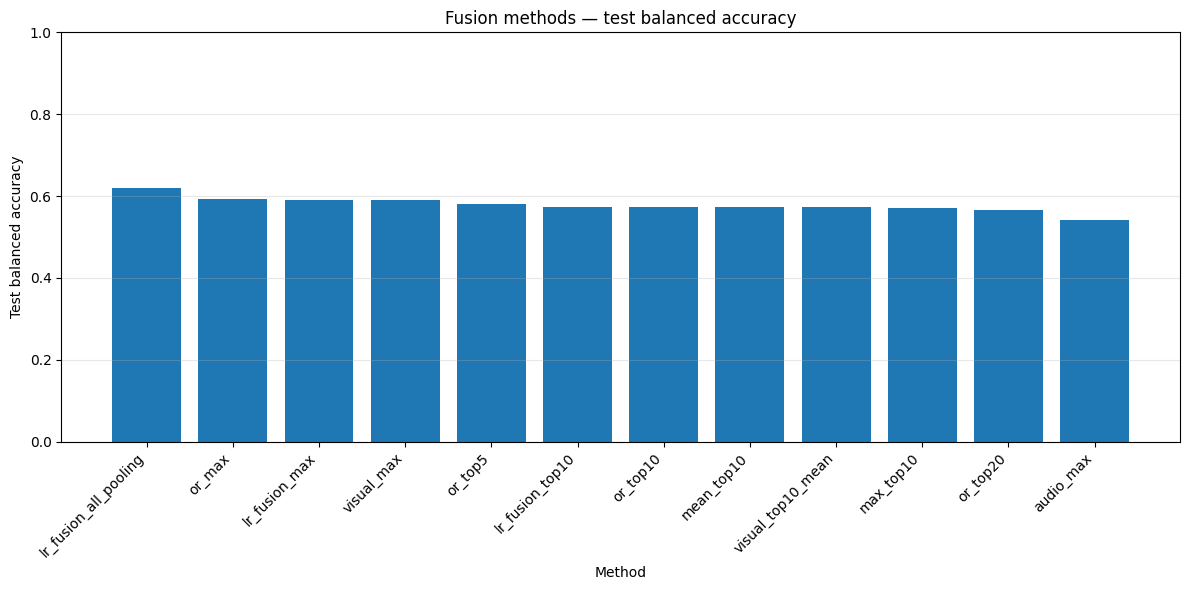

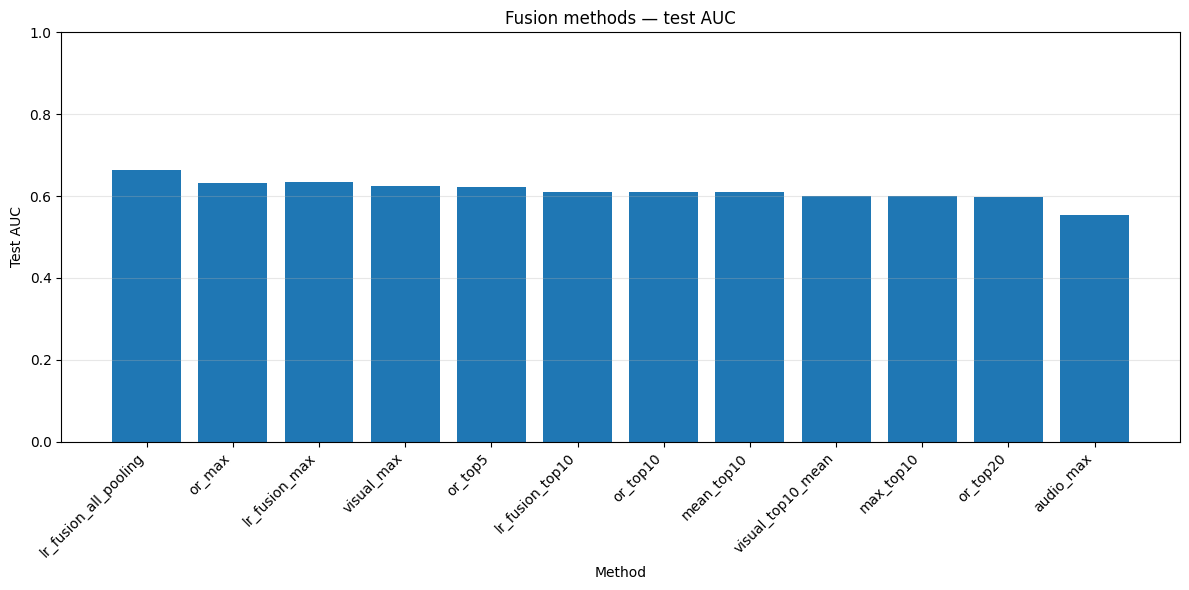

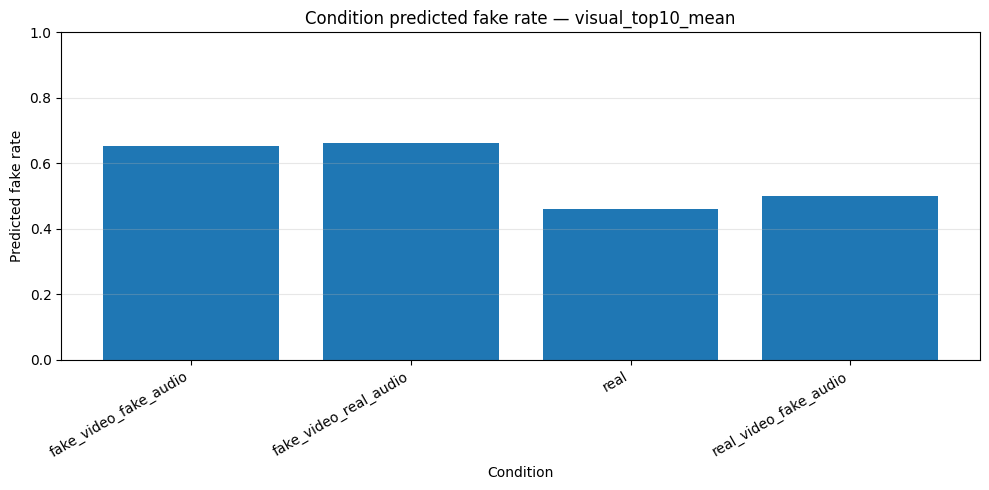

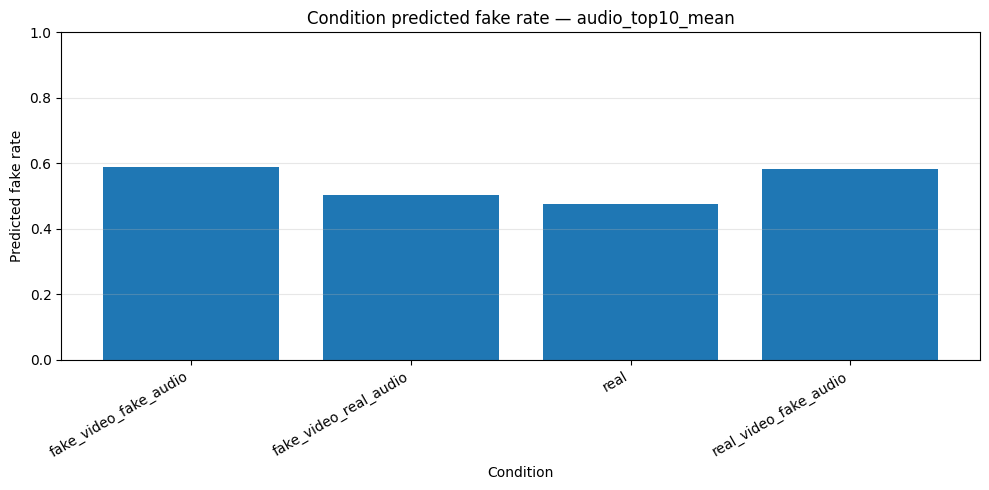

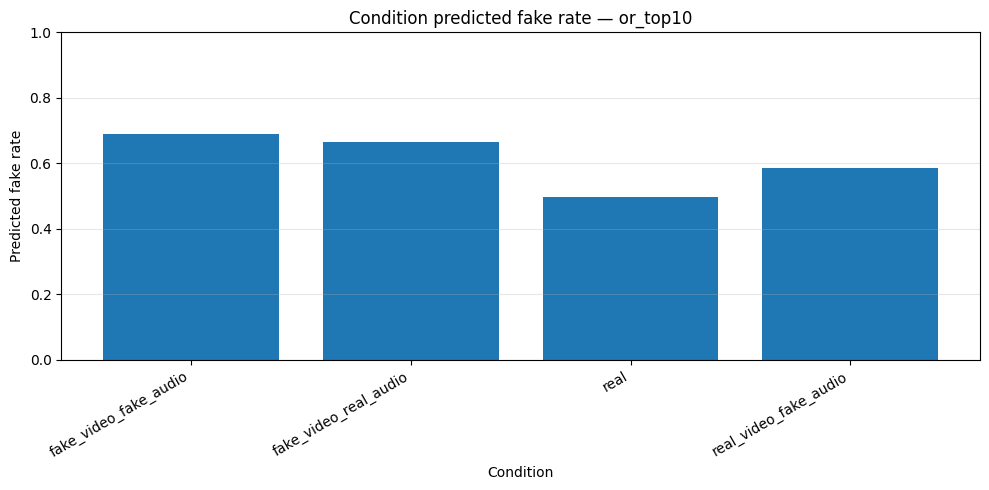

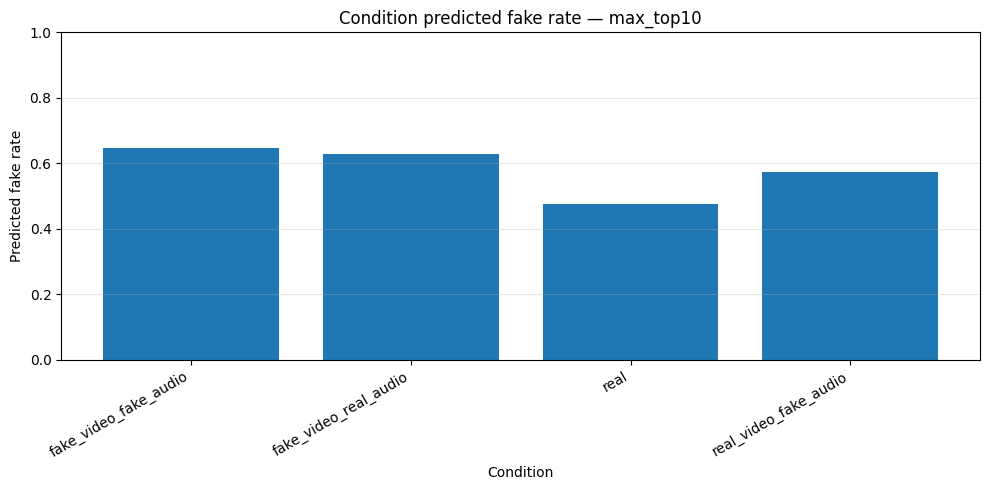

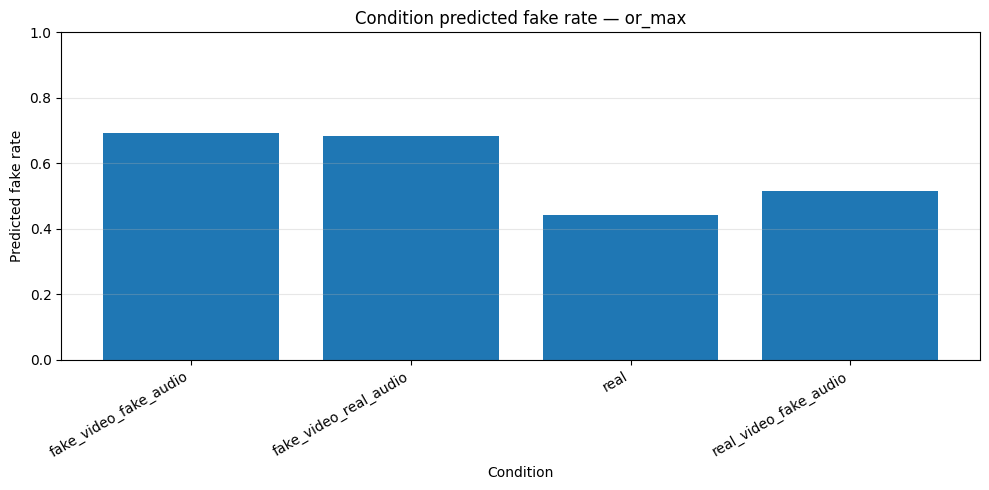

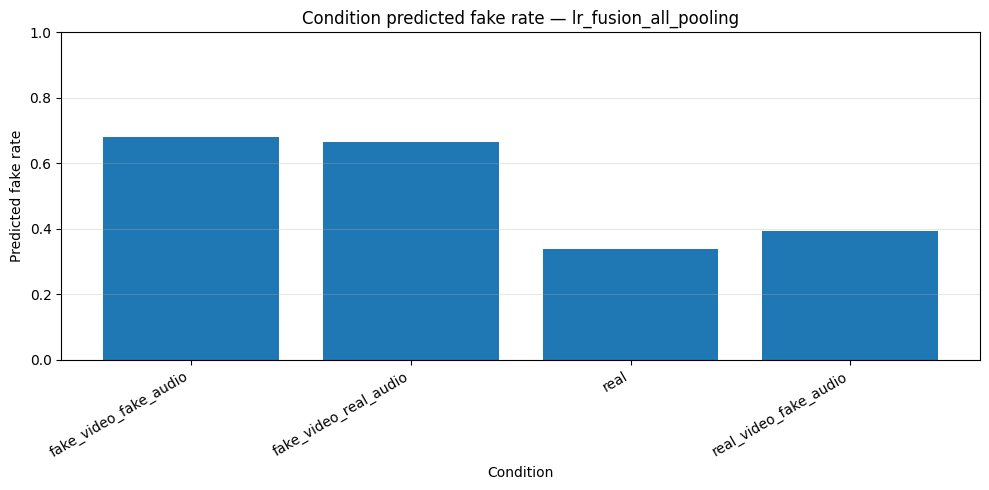

In [20]:
# Cell 17 — Plots

plot_df = test_leaderboard[test_leaderboard["threshold_type"] == "val_tuned_balanced_accuracy"].head(12).copy()
plot_df["label"] = plot_df["method"].astype(str)

plt.figure(figsize=(12, 6))
plt.bar(plot_df["label"], plot_df["balanced_accuracy"])
plt.xlabel("Method")
plt.ylabel("Test balanced accuracy")
plt.title("Fusion methods — test balanced accuracy")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "fusion_test_balanced_accuracy_leaderboard.png", dpi=200)
plt.show()

plt.figure(figsize=(12, 6))
plt.bar(plot_df["label"], plot_df["auc"])
plt.xlabel("Method")
plt.ylabel("Test AUC")
plt.title("Fusion methods — test AUC")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "fusion_test_auc_leaderboard.png", dpi=200)
plt.show()

for method in condition_metrics_df["method"].unique():
    g = condition_metrics_df[condition_metrics_df["method"] == method]
    plt.figure(figsize=(10, 5))
    plt.bar(g["condition"], g["predicted_fake_rate"])
    plt.xlabel("Condition")
    plt.ylabel("Predicted fake rate")
    plt.title(f"Condition predicted fake rate — {method}")
    plt.xticks(rotation=30, ha="right")
    plt.ylim(0, 1)
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    safe_method = "".join(c if c.isalnum() or c in "_-" else "_" for c in method)
    plt.savefig(PLOTS_DIR / f"condition_predicted_fake_rate_{safe_method}.png", dpi=200)
    plt.show()

In [21]:
# Cell 18 — Save concise results summary

best_test = combined_metrics_df[(combined_metrics_df["split"] == "test") & (combined_metrics_df["threshold_type"] == "val_tuned_balanced_accuracy")].sort_values(["balanced_accuracy", "auc"], ascending=False).iloc[0]

summary_md = f"""# {RUN_NAME} Results Summary

## Sources

- Visual source: `{VISUAL_SOURCE_NAME}`
- Audio source: `{AUDIO_SOURCE_NAME}`

## Task

Late fusion for binary any-fake detection on the balanced group-disjoint split.

## Best test method by balanced accuracy

- Method: `{best_test['method']}`
- Balanced accuracy: `{best_test['balanced_accuracy']:.4f}`
- Accuracy: `{best_test['accuracy']:.4f}`
- F1: `{best_test['f1']:.4f}`
- Precision: `{best_test['precision']:.4f}`
- Recall: `{best_test['recall']:.4f}`
- AUC: `{best_test['auc']:.4f}`

## Report points

1. Compare visual-only, audio-only, and fusion on the same common test subset.
2. Prioritise balanced accuracy and AUC over raw accuracy.
3. Use condition metrics to show whether each modality contributes correctly.
4. Discuss whether OR fusion improves fake recall but increases false positives.
5. Discuss whether learned fusion weights the modalities better than simple OR fusion.
"""

summary_path = RUN_DIRS["run"] / "fusion_results_summary.md"
summary_path.write_text(summary_md, encoding="utf-8")
print(summary_md)
print("Saved:", summary_path)

# exp007_late_fusion_bal40k Results Summary

## Sources

- Visual source: `exp004_visual_temporal_bal40k`
- Audio source: `exp005_audio_temporal_bal40k`

## Task

Late fusion for binary any-fake detection on the balanced group-disjoint split.

## Best test method by balanced accuracy

- Method: `lr_fusion_all_pooling`
- Balanced accuracy: `0.6193`
- Accuracy: `0.6193`
- F1: `0.6026`
- Precision: `0.6303`
- Recall: `0.5773`
- AUC: `0.6639`

## Report points

1. Compare visual-only, audio-only, and fusion on the same common test subset.
2. Prioritise balanced accuracy and AUC over raw accuracy.
3. Use condition metrics to show whether each modality contributes correctly.
4. Discuss whether OR fusion improves fake recall but increases false positives.
5. Discuss whether learned fusion weights the modalities better than simple OR fusion.

Saved: /home/jovyan/MSC_PROJECT/experiments/exp007_late_fusion_bal40k/fusion_results_summary.md


In [25]:
# Cell 19 — Save run notes

run_notes = "# " + RUN_NAME + " run notes"
run_notes += "## Purpose Late fusion of visual and audio temporal models for binary any-fake detection."
run_notes += "## Sources"
run_notes += f"- Visual source: {VISUAL_SOURCE_NAME}"
run_notes += f"- Audio source: {AUDIO_SOURCE_NAME}"
run_notes += f"- Visual feature dir: {VISUAL_FEATURE_DIR}"
run_notes += f"- Audio feature dir: {AUDIO_FEATURE_DIR}"
run_notes += "## Fusion target The fusion target is binary_label, where a clip is fake if either the visual modality or audio modality is manipulated."
run_notes += """## Fusion methods

- visual-only temporal score
- audio-only temporal score
- OR fusion
- mean/max score fusion
- logistic regression learned fusion

"""
run_notes += "Fusion uses the common subset of rows present in both visual and audio temporal experiments, matched by relative_path/path."
run_notes += """## Config

```json
" + json.dumps(EXPERIMENT_CONFIG, indent=2) + "
```
"""

run_notes_path = RUN_DIRS["run"] / "run_notes.md"
run_notes_path.write_text(run_notes, encoding="utf-8")
print("Saved:", run_notes_path)

Saved: /home/jovyan/MSC_PROJECT/experiments/exp007_late_fusion_bal40k/run_notes.md


In [27]:
# Cell 20 — Safe final notebook snapshot

def save_final_notebook_snapshot(notebook_path, run_dirs):
    notebook_path = Path(notebook_path)
    snapshot_dir = Path(run_dirs["notebook"])
    snapshot_dir.mkdir(parents=True, exist_ok=True)

    if not notebook_path.exists():
        raise FileNotFoundError(f"Notebook path does not exist: {notebook_path}. Save this notebook there first.")
    if notebook_path.name != NOTEBOOK_FILENAME:
        raise ValueError(f"Refusing to snapshot unexpected notebook name: {notebook_path.name}; expected {NOTEBOOK_FILENAME}")
    size_kb = notebook_path.stat().st_size / 1024
    if size_kb < 10:
        raise ValueError(f"Notebook file looks too small ({size_kb:.1f} KB).")

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    snapshot_path = snapshot_dir / f"final_snapshot_{timestamp}.ipynb"
    shutil.copy2(notebook_path, snapshot_path)
    (snapshot_dir / "snapshot_source.txt").write_text(
        f"Snapshot created at: {datetime.now().isoformat(timespec='seconds')}"
        f"Source notebook: {notebook_path}"
        f"Snapshot path: {snapshot_path}"
        f"Source size KB: {size_kb:.1f}",
        encoding="utf-8",
    )
    print("Final notebook snapshot saved:", snapshot_path)
    return snapshot_path

# Press Ctrl+S before running this cell.
snapshot_path = save_final_notebook_snapshot(NOTEBOOK_PATH, RUN_DIRS)

Final notebook snapshot saved: /home/jovyan/MSC_PROJECT/experiments/exp007_late_fusion_bal40k/notebook/final_snapshot_20260719_174122.ipynb


In [ ]:
# Cell 21 — Archive index and short-path zip export

def create_experiment_index(run_dirs):
    run_dir = Path(run_dirs["run"])
    rows = []
    for section, folder in run_dirs.items():
        folder = Path(folder)
        if not folder.exists() or not folder.is_dir():
            continue
        for file in folder.rglob("*"):
            if file.is_file():
                rows.append({
                    "section": section,
                    "filename": file.name,
                    "path": str(file),
                    "size_mb": file.stat().st_size / 1024**2,
                    "modified_at": datetime.fromtimestamp(file.stat().st_mtime).isoformat(timespec="seconds"),
                })
    df = pd.DataFrame(rows).sort_values(["section", "path"])
    index_path = run_dir / "archive_index.csv"
    df.to_csv(index_path, index=False)
    display(df)
    return df


def safe_filename(name, max_len=60):
    p = Path(name)
    safe = "".join(c if c.isalnum() or c in "._-" else "_" for c in p.stem).strip("_-.") or "file"
    if len(safe) > max_len:
        h = hashlib.md5(safe.encode("utf-8")).hexdigest()[:8]
        safe = safe[:max_len - 9] + "_" + h
    return safe + p.suffix


def zip_experiment_shortpaths(run_dir, exports_dir, short_name, max_filename_len=60):
    run_dir = Path(run_dir)
    exports_dir = Path(exports_dir)
    exports_dir.mkdir(parents=True, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    zip_path = exports_dir / f"{short_name}_{timestamp}.zip"
    mapping_rows = []
    folder_replacements = {"checkpoints":"ckpt", "manifests":"man", "results":"res", "plots":"plt", "notebook":"nb"}

    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zipf:
        for file in run_dir.rglob("*"):
            if not file.is_file() or ".ipynb_checkpoints" in file.parts:
                continue
            rel = file.relative_to(run_dir)
            parts = [folder_replacements.get(part, safe_filename(part, max_len=30)) for part in rel.parts[:-1]]
            parts.append(safe_filename(rel.parts[-1], max_len=max_filename_len))
            arcname = Path(short_name, *parts)
            zipf.write(file, arcname=str(arcname))
            mapping_rows.append({"original_path": str(file), "archive_path": str(arcname)})
        zipf.writestr(f"{short_name}/archive_path_mapping.csv", pd.DataFrame(mapping_rows).to_csv(index=False))
    print("Created:", zip_path)
    print(f"Size: {zip_path.stat().st_size / 1024**2:.2f} MB")
    return zip_path

experiment_index_df = create_experiment_index(RUN_DIRS)
zip_path = zip_experiment_shortpaths(RUN_DIRS["run"], EXPORTS_DIR, RUN_NAME)
display(FileLink(str(zip_path)))

# What to report from Experiment 007

Main metrics:

```text
1. Visual-only binary performance on the common test subset
2. Audio-only binary performance on the common test subset
3. OR fusion performance
4. Learned logistic-regression fusion performance
5. Condition-level predicted fake rates
```

Suggested wording:

```text
Late fusion was evaluated by combining visual temporal and audio temporal model scores on the shared balanced test split. Rule-based OR fusion was used to model the assumption that a sample should be classified as fake if either modality appears manipulated, while a logistic-regression fusion model tested whether the two modality scores could be weighted automatically. Condition-level analysis was used to assess whether fusion improved detection of video-only, audio-only, and audio-visual manipulations compared with the unimodal models.
```